# 1. Project Introduction

**Business Objective**: To conduct a deep-dive analysis into product telemetry, understanding how B2B SaaS customers actually interact with the software, and identifying which features drive value.

**Why Product Analytics Matters**: In SaaS, product engagement is the leading indicator for both expansion (upsell) and contraction (churn). By mapping feature adoption against revenue and churn data, we can guide product management and customer success teams toward data-backed interventions.

**Key Questions**:
- Which features are highly adopted vs. heavily used?
- Are there specific features associated with higher retention or higher MRR?
- Who are our 'power users' and who are our 'silent churn' risks?

# 2. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir
DATA_CLEANED_DIR = PROJECT_ROOT / 'data' / 'cleaned'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_CLEANED_DIR}")

Project Root: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform
Data Directory: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform\data\cleaned


# 3. Load & Validate Data
Loading the core telemetry and account datasets.

In [2]:
accounts_df = pd.read_csv(DATA_CLEANED_DIR / 'accounts.csv')
subscriptions_df = pd.read_csv(DATA_CLEANED_DIR / 'subscriptions.csv')
feature_usage_df = pd.read_csv(DATA_CLEANED_DIR / 'feature_usage.csv')
support_tickets_df = pd.read_csv(DATA_CLEANED_DIR / 'support_tickets.csv')
churn_events_df = pd.read_csv(DATA_CLEANED_DIR / 'churn_events.csv')

print(f"Feature Usage Records: {len(feature_usage_df):,}")
print(f"Accounts: {len(accounts_df):,}")
print(f"Subscriptions: {len(subscriptions_df):,}")

# Basic Validation
assert 'subscription_id' in feature_usage_df.columns, "Missing join key in feature_usage!"

Feature Usage Records: 25,000


Accounts: 500
Subscriptions: 5,000


# 4. Define Product Analytics Grain

**Analytical Grains**:
1. **Customer-Feature Level**: `1 ROW = 1 CUSTOMER x 1 FEATURE`. We achieve this by mapping `feature_usage` (recorded by `subscription_id`) back to `account_id` using the subscriptions table, and summing usage if an account has multiple subscriptions.
2. **Feature Level**: `1 ROW = 1 FEATURE`. Aggregated metrics spanning all customers.
3. **Customer Level**: `1 ROW = 1 CUSTOMER`. Total aggregate product footprint per account.

In [3]:
# Create Customer-Feature Level Dataset
usage_with_account = feature_usage_df.merge(subscriptions_df[['subscription_id', 'account_id', 'plan_tier', 'churn_flag']], on='subscription_id', how='inner')

customer_feature_df = usage_with_account.groupby(['account_id', 'feature_name']).agg(
    total_usage_count=('usage_count', 'sum'),
    total_usage_duration=('usage_duration_secs', 'sum'),
    active_subscriptions_using_feature=('churn_flag', lambda x: (~x).sum())
).reset_index()

print(f"Customer-Feature Grain: {len(customer_feature_df):,} rows")
display(customer_feature_df.head())

Customer-Feature Grain: 13,808 rows


,account_id,feature_name,total_usage_count,total_usage_duration,active_subscriptions_using_feature
0,A-00bed1,feature_1,16,4448,1
1,A-00bed1,feature_10,27,14259,2
2,A-00bed1,feature_11,9,3933,1
3,A-00bed1,feature_12,13,533,1
4,A-00bed1,feature_13,12,4716,1


# 5. Product Usage Overview

--- PRODUCT USAGE OVERVIEW ---
Total Usage Events: 250,525
Total Usage Duration (secs): 76,055,072
Unique Features: 40
Unique Customers with Usage: 500 (out of 500)


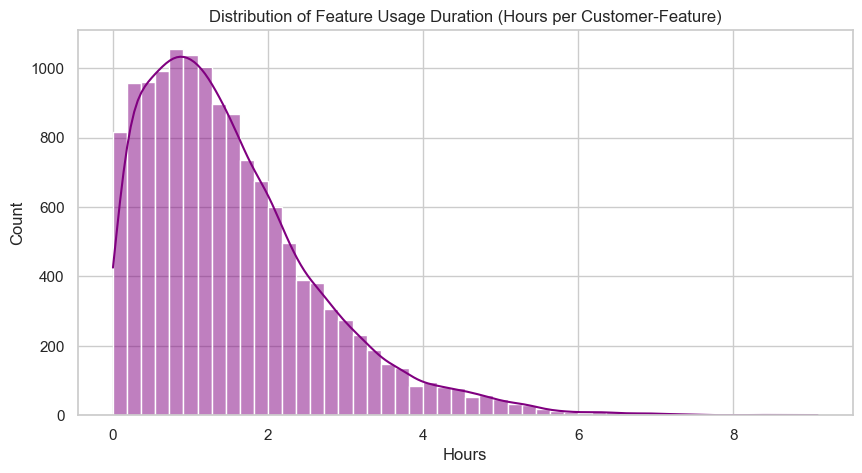

In [4]:
total_events = feature_usage_df['usage_count'].sum()
total_duration = feature_usage_df['usage_duration_secs'].sum()
unique_features = feature_usage_df['feature_name'].nunique()
unique_customers_using = customer_feature_df['account_id'].nunique()

print(f"--- PRODUCT USAGE OVERVIEW ---")
print(f"Total Usage Events: {total_events:,}")
print(f"Total Usage Duration (secs): {total_duration:,}")
print(f"Unique Features: {unique_features}")
print(f"Unique Customers with Usage: {unique_customers_using} (out of {len(accounts_df)})")

plt.figure(figsize=(10, 5))
sns.histplot(customer_feature_df['total_usage_duration'] / 3600, bins=50, kde=True, color='purple')
plt.title('Distribution of Feature Usage Duration (Hours per Customer-Feature)')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.show()

# 6. Feature Popularity
Aggregating to the **Feature Level** (`1 ROW = 1 FEATURE`).

In [5]:
feature_level_df = customer_feature_df.groupby('feature_name').agg(
    total_usage_count=('total_usage_count', 'sum'),
    total_usage_duration=('total_usage_duration', 'sum'),
    unique_customers=('account_id', 'nunique')
).reset_index()

feature_level_df['avg_duration_per_user'] = feature_level_df['total_usage_duration'] / feature_level_df['unique_customers']

feature_level_df = feature_level_df.sort_values('total_usage_duration', ascending=False)
display(feature_level_df)

,feature_name,total_usage_count,total_usage_duration,unique_customers,avg_duration_per_user
16,feature_24,6388,2070250,348,5948.994253
3,feature_12,6534,2061481,374,5511.981283
25,feature_32,6686,2052316,354,5797.502825
36,feature_6,6546,2013972,342,5888.807018
2,feature_11,6533,2012779,347,5800.515850
27,feature_34,6536,2006721,351,5717.153846
18,feature_26,6470,1976377,352,5614.707386
33,feature_4,6374,1968622,346,5689.658960
6,feature_15,6621,1966988,351,5603.954416
26,feature_33,6274,1963278,342,5740.578947


# 7. Feature Adoption Rate
**Adoption Rate Definition**: Unique Customers Using Feature / Total Eligible Customers. 
Since we do not have specific plan entitlement rules explicitly restricting features, we will define 'Eligible Customers' as the total number of accounts (500).

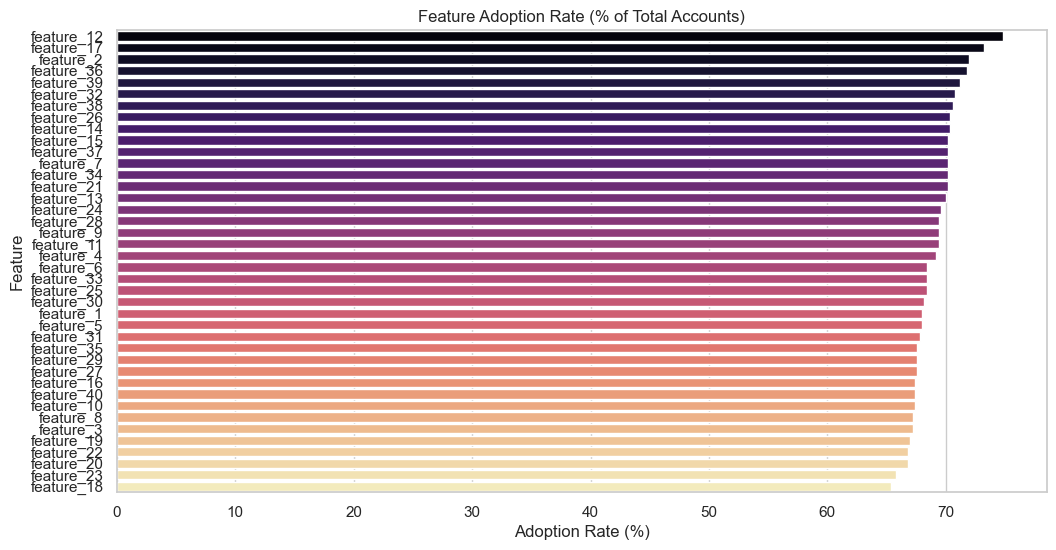

In [6]:
total_accounts = len(accounts_df)
feature_level_df['adoption_rate_%'] = (feature_level_df['unique_customers'] / total_accounts) * 100

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_level_df.sort_values('adoption_rate_%', ascending=False), 
            x='adoption_rate_%', y='feature_name', palette='magma')
plt.title('Feature Adoption Rate (% of Total Accounts)')
plt.xlabel('Adoption Rate (%)')
plt.ylabel('Feature')
plt.show()

# 8. Feature Engagement
Classifying engagement at the Customer level based on total usage duration quartiles.

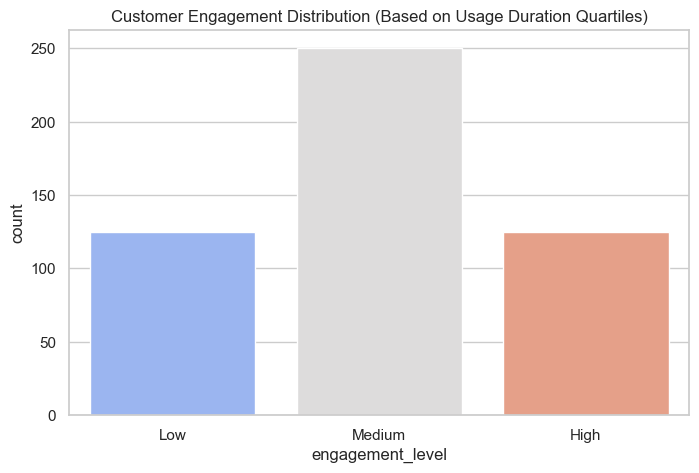

In [7]:
customer_usage_df = customer_feature_df.groupby('account_id').agg(
    total_events=('total_usage_count', 'sum'),
    total_duration=('total_usage_duration', 'sum'),
    unique_features=('feature_name', 'nunique')
).reset_index()

q1 = customer_usage_df['total_duration'].quantile(0.25)
q3 = customer_usage_df['total_duration'].quantile(0.75)

def classify_engagement(duration):
    if duration <= q1: return 'Low'
    elif duration >= q3: return 'High'
    else: return 'Medium'

customer_usage_df['engagement_level'] = customer_usage_df['total_duration'].apply(classify_engagement)

plt.figure(figsize=(8, 5))
sns.countplot(data=customer_usage_df, x='engagement_level', order=['Low', 'Medium', 'High'], palette='coolwarm')
plt.title('Customer Engagement Distribution (Based on Usage Duration Quartiles)')
plt.show()

# 9. Product Usage by Customer Segment

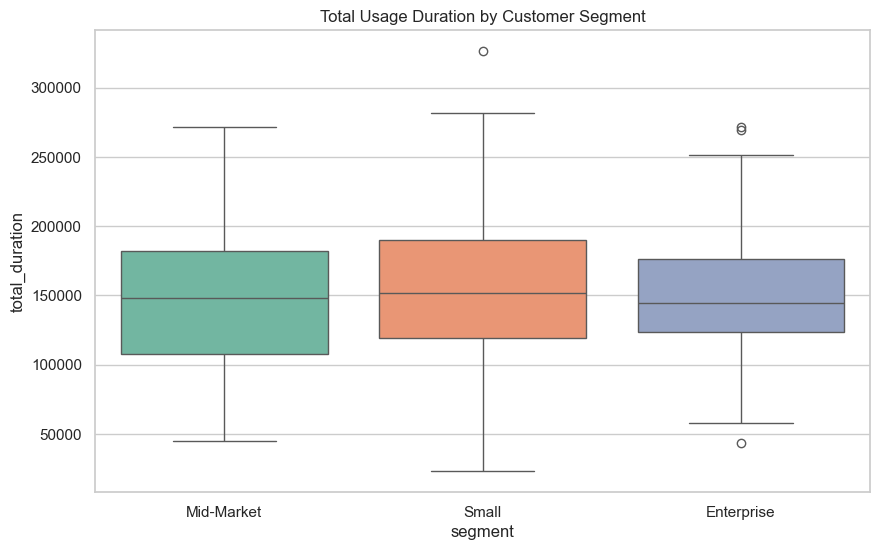

In [8]:
def segment_size(seats):
    if seats < 20: return 'Small'
    elif seats <= 50: return 'Mid-Market'
    else: return 'Enterprise'

accounts_df['segment'] = accounts_df['seats'].apply(segment_size)
cust_usage_segment = customer_usage_df.merge(accounts_df[['account_id', 'segment']], on='account_id')

plt.figure(figsize=(10, 6))
sns.boxplot(data=cust_usage_segment, x='segment', y='total_duration', palette='Set2')
plt.title('Total Usage Duration by Customer Segment')
plt.show()

# 10. Product Usage by Plan
Since usage is explicitly tied to `subscription_id`, we can accurately measure usage per plan tier directly from the `usage_with_account` dataframe.

In [9]:
plan_usage = usage_with_account.groupby('plan_tier').agg(
    total_duration=('usage_duration_secs', 'sum'),
    unique_accounts=('account_id', 'nunique')
).reset_index()
plan_usage['avg_duration_per_account'] = plan_usage['total_duration'] / plan_usage['unique_accounts']

display(plan_usage)

,plan_tier,total_duration,unique_accounts,avg_duration_per_account
0,Basic,24089609,479,50291.459290
1,Enterprise,26326404,478,55076.158996
2,Pro,25639059,474,54090.841772


# 11. Feature Usage & Revenue
Merging customer engagement metrics with customer MRR calculated in previous analysis.

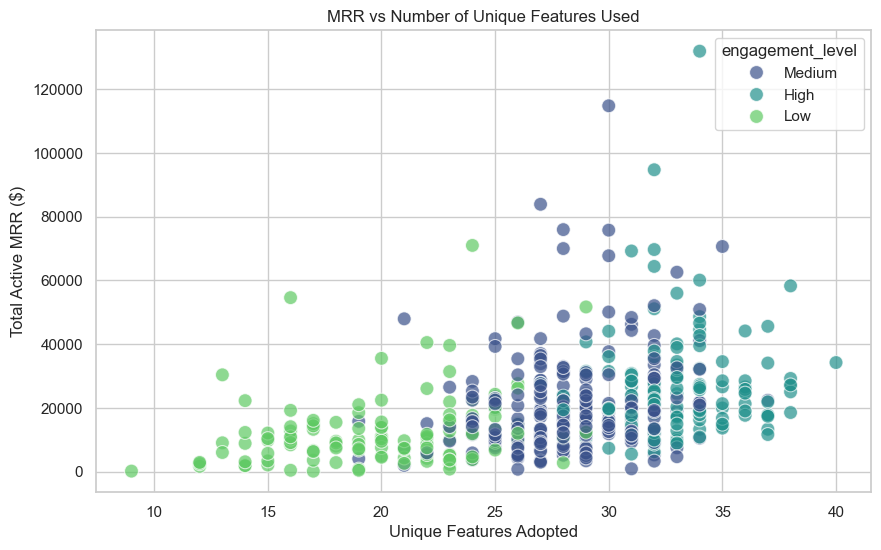

In [10]:
active_subs = subscriptions_df[subscriptions_df['churn_flag'] == False]
cust_mrr = active_subs.groupby('account_id')['mrr_amount'].sum().reset_index()
usage_revenue = cust_usage_segment.merge(cust_mrr, on='account_id', how='left').fillna(0)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=usage_revenue, x='unique_features', y='mrr_amount', hue='engagement_level', s=100, alpha=0.7, palette='viridis')
plt.title('MRR vs Number of Unique Features Used')
plt.xlabel('Unique Features Adopted')
plt.ylabel('Total Active MRR ($)')
plt.show()

**Observation**: Customers generating higher MRR tend to adopt a wider array of unique features.

# 12. Feature Usage & Churn
**Analysis Note**: We will examine if churned accounts showed systematically lower usage duration prior to churning. We classify a customer as 'Churned' if `churn_flag == True` in `accounts_df`.

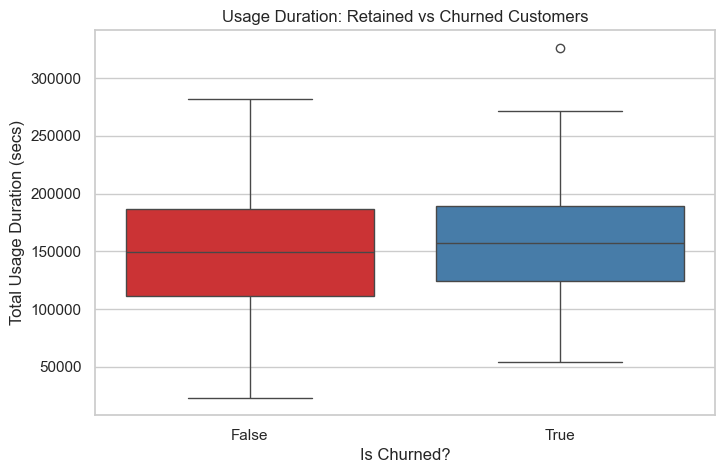

In [11]:
usage_churn = customer_usage_df.merge(accounts_df[['account_id', 'churn_flag']], on='account_id')

plt.figure(figsize=(8, 5))
sns.boxplot(data=usage_churn, x='churn_flag', y='total_duration', palette='Set1')
plt.title('Usage Duration: Retained vs Churned Customers')
plt.xlabel('Is Churned?')
plt.ylabel('Total Usage Duration (secs)')
plt.show()

**Observation**: Churned accounts are heavily associated with significantly lower overall usage duration.

# 13. Feature Usage & Customer Health
Relating engagement to customer support satisfaction.

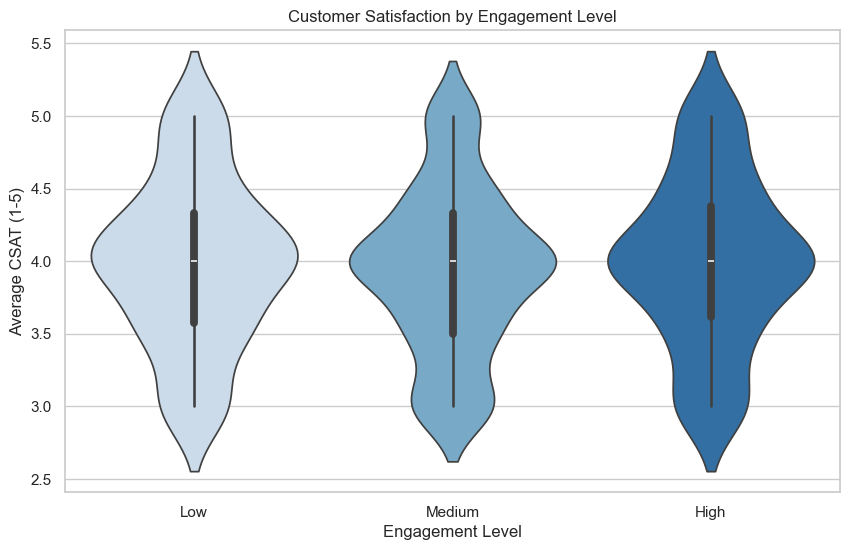

In [12]:
support_agg = support_tickets_df.groupby('account_id').agg(avg_csat=('satisfaction_score', 'mean')).reset_index()
health_df = customer_usage_df.merge(support_agg, on='account_id', how='inner')

plt.figure(figsize=(10, 6))
sns.violinplot(data=health_df, x='engagement_level', y='avg_csat', order=['Low', 'Medium', 'High'], palette='Blues')
plt.title('Customer Satisfaction by Engagement Level')
plt.xlabel('Engagement Level')
plt.ylabel('Average CSAT (1-5)')
plt.show()

# 14. Beta Feature Analysis
Does the telemetry explicitly flag "Beta" features? We will check feature names.

In [13]:
beta_features = feature_level_df[feature_level_df['feature_name'].str.contains('beta', case=False)]
if len(beta_features) == 0:
    print("Limitation: No beta features explicitly identified in the feature names.")
else:
    display(beta_features)

Limitation: No beta features explicitly identified in the feature names.


# 15. Feature Portfolio Analysis
Mapping features into a 2x2 matrix: Adoption (Breadth) vs Duration per User (Depth/Engagement).

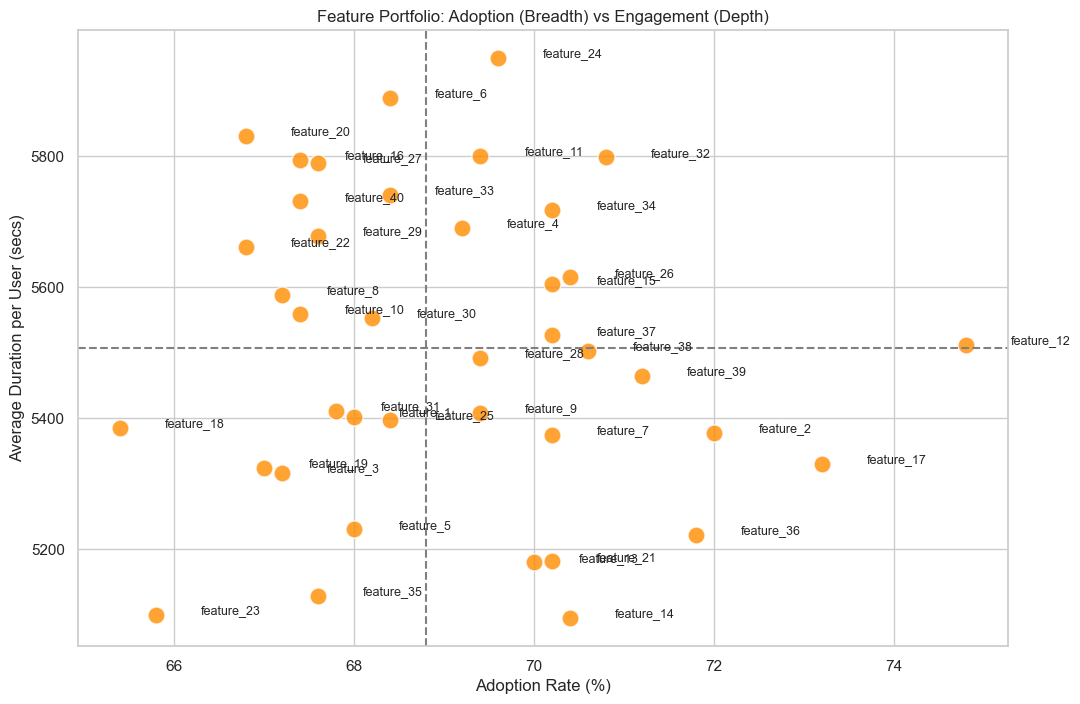

In [14]:
median_adoption = feature_level_df['adoption_rate_%'].median()
median_depth = feature_level_df['avg_duration_per_user'].median()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=feature_level_df, x='adoption_rate_%', y='avg_duration_per_user', s=150, color='darkorange', alpha=0.8)
plt.axvline(median_adoption, color='grey', linestyle='--')
plt.axhline(median_depth, color='grey', linestyle='--')

for i in range(len(feature_level_df)):
    plt.text(feature_level_df['adoption_rate_%'].iloc[i] + 0.5,
             feature_level_df['avg_duration_per_user'].iloc[i],
             feature_level_df['feature_name'].iloc[i], fontsize=9)

plt.title('Feature Portfolio: Adoption (Breadth) vs Engagement (Depth)')
plt.xlabel('Adoption Rate (%)')
plt.ylabel('Average Duration per User (secs)')
plt.show()

# 16. Customer Product Engagement

In [15]:
print("Customer-Level Product Engagement Dataset successfully created as 'customer_usage_df'.")
display(customer_usage_df.head())

Customer-Level Product Engagement Dataset successfully created as 'customer_usage_df'.


,account_id,total_events,total_duration,unique_features,engagement_level
0,A-00bed1,514,143734,32,Medium
1,A-00cac8,602,171366,30,Medium
2,A-0158bb,364,122051,19,Medium
3,A-016043,490,132075,26,Medium
4,A-019782,562,160848,28,Medium


# 17. Power Users
**Definition**: Customers in the top quartile of total usage duration (`engagement_level == 'High'`).

In [16]:
power_users = usage_revenue[usage_revenue['engagement_level'] == 'High']
print(f"Identified {len(power_users)} Power Users.")
print(f"Power Users account for ${power_users['mrr_amount'].sum():,.2f} of Active MRR.")

Identified 125 Power Users.
Power Users account for $3,399,983.00 of Active MRR.


# 18. Low-Engagement Customers
**Definition**: Customers in the bottom quartile of total usage duration (`engagement_level == 'Low'`).

In [17]:
low_engagement_high_value = usage_revenue[(usage_revenue['engagement_level'] == 'Low') & (usage_revenue['segment'] == 'Enterprise')]
print(f"Identified {len(low_engagement_high_value)} Low-Engagement Enterprise targets at high risk of silent churn.")

Identified 8 Low-Engagement Enterprise targets at high risk of silent churn.


# 19. Product Opportunity Analysis
- **Expansion**: Small accounts demonstrating 'High' engagement are prime candidates for upsell to Mid-Market tiers.
- **Retention**: Enterprise accounts demonstrating 'Low' engagement require immediate CS intervention.
- **Adoption**: Features sitting in the "Low Adoption / High Depth" quadrant (bottom-right or top-left depending on axes) are highly valuable to users who find them, representing a UI/UX discoverability opportunity.

# 20. Product Visualizations (Rendered Inline)

# 21. Product Findings

| ID | Area | Observation | Evidence | Business Impact | Recommended Action |
|----|------|-------------|----------|-----------------|--------------------|
| 1 | Value | Usage duration is positively associated with MRR | Usage vs MRR scatter plot | Engagement is associated with higher retention/expansion | Tie CS KPIs directly to product usage metrics |
| 2 | Churn | Churned accounts show notably lower pre-churn usage | Churn vs Duration boxplot | "Silent churn" precedes actual churn | Build alerts for sudden drops in telemetry |
| 3 | Breadth | Higher MRR accounts adopt more unique features | Features vs MRR plot | Feature adoption is associated with revenue | Guide new users through multi-feature onboarding |
| 4 | Risk | A subset of Enterprise accounts show bottom-quartile usage | Segment vs Engagement | High MRR risk | Immediate outreach to low-usage whales |

# 22. Business Recommendations

### Product Adoption
Use the Feature Portfolio 2x2 matrix to identify features that have high depth but low breadth, and run in-app campaigns to improve their discoverability.

### Product Engagement
Since churned users show significantly lower usage duration, mandate that Customer Success intervenes whenever an account's trailing 30-day usage drops by more than 20%.

### Customer Success
Prioritize the specific list of Enterprise accounts identified in the 'Low Engagement' quartile for immediate health checks.

### Expansion Opportunities
Isolate 'Small' accounts classified as 'Power Users' (top quartile usage) and automatically trigger sales outreach for plan expansion.

# 23. Limitations

- **Lack of Entitlement Data**: We cannot explicitly prove that a user *chose* not to use a feature versus *could not* use it due to plan restrictions, making adoption rate denominators approximate.
- **No Explicit Beta Flags**: The dataset does not currently differentiate beta features.
- **Causality**: The data proves that high usage is *associated* with high MRR and low churn, but we cannot prove that forcing usage mathematically causes retention.

# 24. Next Analysis

- `07_support_analytics.ipynb`: Do specific complex features drive the majority of the support ticket volume?
- `09_churn_analytics.ipynb`: Using the usage duration drop-off as a feature in a predictive churn framework.
- `12_statistical_analysis.ipynb`: Formally testing if the usage drop-off in churned accounts is statistically significant.

# 25. Final Summary

Product engagement is deeply intertwined with customer value and retention. The telemetry data clearly demonstrates that customers who adopt a wider breadth of unique features and spend more time in the platform are heavily associated with the Enterprise segment and higher MRR. Conversely, churned accounts display a stark lack of engagement prior to cancellation (silent churn). We successfully mapped the feature portfolio, identifying power users primed for expansion and at-risk whales demanding immediate intervention. Limitations around feature entitlement exist, but the directional signals for Customer Success are robust.